# Text-GAN Variant: Synthetic Financial Tweet Generation

This notebook implements a lightweight text-based Generative Adversarial Network (GAN) for synthetic financial tweet generation. The model is trained on the prepared financial sentiment tweet corpus and uses an adversarial setup: the generator attempts to produce realistic token sequences, while the discriminator attempts to distinguish real dataset entries from generated samples.

The purpose of this variant is not only to generate synthetic text, but also to observe the performance limits of GAN-style learning when applied to discrete language tokens. The results and discussion in this notebook focus only on the Text-GAN pipeline.


In [1]:
# %pip install nltk pandas matplotlib scikit-learn torch rouge-score -q

## Notebook Objective

The goal of this notebook is to build and evaluate a sequence-based Text-GAN using PyTorch. The generator receives random noise and produces token sequences, while the discriminator receives either real encoded tweets or generated token sequences and predicts whether each sequence is real or fake.

This notebook evaluates two parts of the GAN separately. The discriminator is evaluated using classification metrics such as precision, recall, and F1-score. The generator is evaluated using BLEU and ROUGE scores, along with qualitative inspection of generated samples.

## Environment and Library Setup

This section imports the libraries used for data handling, tokenization, model construction, training, and evaluation. PyTorch is used for the GAN architecture and optimization. NLTK tokenization and traditional text-generation metrics are used to evaluate the generated samples.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import re
import os
import json
from pathlib import Path

from nltk.tokenize import wordpunct_tokenize
from collections import Counter
from sklearn.metrics import precision_recall_fscore_support, classification_report
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer

def tokenize(text):
    return wordpunct_tokenize(str(text).lower())

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## Dataset Loading

The GAN uses the same preprocessed dataset split as the other variants, but this notebook only depends on the cleaned text column. The training split is used to build the vocabulary and train the adversarial model, while the test split is used to compare real and generated text during evaluation.


In [3]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "dataset").exists() and (PROJECT_ROOT.parent / "dataset").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "dataset"
RESULTS_DIR = PROJECT_ROOT / "results"

train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "val.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")

for df in (train_df, val_df, test_df):
    df["clean_text"] = df["clean_text"].fillna("").astype(str)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
train_df["clean_text"].head(3)

Train: 9425 | Val: 1194 | Test: 1194


0    <STOCK> - JPMorgan reels in expectations on Be...
1    <STOCK> <STOCK> - Nomura points to bookings we...
2    <STOCK> - Cemex cut at Credit Suisse, J.P. Mor...
Name: clean_text, dtype: str

## Vocabulary and Tokenization

The Text-GAN uses a custom vocabulary built from the training set instead of a pretrained subword tokenizer. The most frequent tokens are kept, while less common or unseen tokens are mapped to `<UNK>`. Special tokens are added for padding, unknown words, sequence start, and sequence end.

This design keeps the GAN lightweight, but it also limits generation quality. Since the model can only generate tokens from this fixed vocabulary, unfamiliar words and rare financial terms may appear as `<UNK>` or may be excluded entirely.


In [4]:
VOCAB_SIZE  = 5000
MAX_SEQ_LEN = 30       # most tweets fit within 30 tokens
PAD_TOKEN   = "<PAD>"
UNK_TOKEN   = "<UNK>"
SOS_TOKEN   = "<SOS>"
EOS_TOKEN   = "<EOS>"

all_tokens = []
for text in train_df["clean_text"]:
    all_tokens.extend(tokenize(text))

counter = Counter(all_tokens)
most_common = [tok for tok, _ in counter.most_common(VOCAB_SIZE - 4)]

vocab = [PAD_TOKEN, UNK_TOKEN, SOS_TOKEN, EOS_TOKEN] + most_common
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

PAD_IDX = word2idx[PAD_TOKEN]
UNK_IDX = word2idx[UNK_TOKEN]
SOS_IDX = word2idx[SOS_TOKEN]
EOS_IDX = word2idx[EOS_TOKEN]

print(f"Vocabulary size: {len(vocab)}")

Vocabulary size: 5000


## Sequence Encoding

Each tweet is converted into a fixed-length sequence of token IDs. The model adds a start token, appends an end token, and pads shorter sequences so that all inputs have the same length.


In [5]:
def encode(text, max_len=MAX_SEQ_LEN):
    tokens = tokenize(text)[:max_len]
    ids = [SOS_IDX] + [word2idx.get(t, UNK_IDX) for t in tokens] + [EOS_IDX]
    # Pad or truncate to fixed length
    ids = ids[:max_len]
    ids += [PAD_IDX] * (max_len - len(ids))
    return ids

def decode(ids):
    tokens = []
    for i in ids:
        tok = idx2word.get(i, UNK_TOKEN)
        if tok in (PAD_TOKEN, SOS_TOKEN, EOS_TOKEN):
            continue
        tokens.append(tok)
    return " ".join(tokens)

# Encode all splits
train_encoded = [encode(t) for t in train_df["clean_text"]]
test_encoded  = [encode(t) for t in test_df["clean_text"]]

print(f"Sample encoded: {train_encoded[0]}")
print(f"Sample decoded: {decode(train_encoded[0])}")

Sample encoded: [2, 10, 6, 12, 5, 802, 4855, 16, 413, 18, 920, 1161, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Sample decoded: < stock > - jpmorgan reels in expectations on beyond meat


## DataLoader Preparation

The encoded tweets are wrapped in a PyTorch dataset and loaded in mini-batches. Fixed batch sizes make the adversarial training loop easier to manage because the generator and discriminator receive matching real and fake batch sizes.


In [6]:
class TweetDataset(Dataset):
    def __init__(self, encoded_sequences):
        self.data = torch.tensor(encoded_sequences, dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

BATCH_SIZE = 64

train_dataset = TweetDataset(train_encoded)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                           shuffle=True, drop_last=True)

print(f"Batches per epoch: {len(train_loader)}")

Batches per epoch: 147


## Generator Architecture

The generator is an RNN-based sequence generator. It projects a random noise vector into an initial hidden state, then uses a GRU to generate a sequence one token at a time. During training, Gumbel-softmax is used so that the generator can pass differentiable soft token distributions to the discriminator.


In [7]:
class Generator(nn.Module):
    """
    Noise vector → GRU → linear projection over vocab
    Outputs a sequence of token logits (one per timestep).
    """
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128,
                 seq_len=MAX_SEQ_LEN, noise_dim=100):
        super().__init__()
        self.seq_len    = seq_len
        self.hidden_dim = hidden_dim
        self.noise_dim  = noise_dim

        self.fc_noise = nn.Linear(noise_dim, hidden_dim)
        self.embed    = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.gru      = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.out      = nn.Linear(hidden_dim, vocab_size)

    def forward(self, noise, temperature=1.0, hard=False):
        batch = noise.size(0)

        # Project noise into initial hidden state
        h0 = torch.tanh(self.fc_noise(noise)).unsqueeze(0)  # (1, B, H)

        # Start token for every item in batch
        inp = torch.full((batch, 1), SOS_IDX,
                         dtype=torch.long, device=noise.device)
        inp_emb = self.embed(inp)

        logits_seq = []
        token_seq  = []
        soft_seq   = []

        for _ in range(self.seq_len):
            emb, h0     = self.gru(inp_emb, h0)             # (B,1,H)
            logits      = self.out(emb.squeeze(1))          # (B, V)
            logits_seq.append(logits.unsqueeze(1))

            # Gumbel-softmax keeps the generator path differentiable.
            soft_tok = F.gumbel_softmax(logits, tau=temperature,
                                        hard=hard, dim=-1)  # (B, V)
            next_tok = soft_tok.argmax(dim=-1, keepdim=True)
            token_seq.append(next_tok)
            soft_seq.append(soft_tok.unsqueeze(1))
            inp_emb = soft_tok @ self.embed.weight          # (B, E)
            inp_emb = inp_emb.unsqueeze(1)                  # (B, 1, E)

        logits_all = torch.cat(logits_seq, dim=1)   # (B, T, V)
        tokens_all = torch.cat(token_seq,  dim=1)   # (B, T)
        soft_all   = torch.cat(soft_seq,   dim=1)   # (B, T, V)
        return logits_all, tokens_all, soft_all

## Discriminator Architecture

The discriminator is a 1D-CNN classifier. It embeds token sequences, applies convolution filters with multiple kernel sizes, pools the resulting features, and predicts whether the input sequence is real or fake. This allows the discriminator to detect local n-gram patterns that commonly appear in real tweets.


In [8]:
class Discriminator(nn.Module):
    """
    Token sequence → Embedding → 1D-CNN → sigmoid (real / fake)
    """
    def __init__(self, vocab_size, embed_dim=64, num_filters=128,
                 seq_len=MAX_SEQ_LEN):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # Multiple kernel sizes to capture n-gram features
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, kernel_size=k, padding=k // 2)
            for k in [3, 4, 5]
        ])
        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(num_filters * 3, 1)

    def forward(self, tokens=None, token_probs=None):
        # tokens: (B, T); token_probs: (B, T, V) differentiable soft tokens
        if token_probs is not None:
            x = token_probs @ self.embed.weight      # (B, T, E)
        else:
            x = self.embed(tokens)                   # (B, T, E)
        x = x.permute(0, 2, 1)                       # (B, E, T)
        pooled = []
        for conv in self.convs:
            c = torch.relu(conv(x))                  # (B, F, T')
            c = c.max(dim=2).values                  # (B, F)
            pooled.append(c)
        x = torch.cat(pooled, dim=1)                 # (B, F*3)
        x = self.dropout(x)
        return torch.sigmoid(self.fc(x))             # (B, 1)

## Model Configuration

This section defines the major hyperparameters for the GAN, including the noise dimension, embedding size, hidden size, number of discriminator filters, and learning rates. The generator and discriminator are initialized separately because they have different objectives and optimization dynamics.


In [9]:
NOISE_DIM  = 100
EMBED_DIM  = 64
HIDDEN_DIM = 128
NUM_FILTERS = 128
LR_G = 2e-4
LR_D = 1e-4

G = Generator(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    seq_len=MAX_SEQ_LEN,
    noise_dim=NOISE_DIM
).to(DEVICE)

D = Discriminator(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    num_filters=NUM_FILTERS,
    seq_len=MAX_SEQ_LEN
).to(DEVICE)

opt_G = optim.Adam(G.parameters(), lr=LR_G, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=LR_D, betas=(0.5, 0.999))

criterion = nn.BCELoss()

print(f"Generator params    : {sum(p.numel() for p in G.parameters()):,}")
print(f"Discriminator params: {sum(p.numel() for p in D.parameters()):,}")

Generator params    : 1,052,424
Discriminator params: 419,073


In [10]:
def real_labels(size):
    # Smooth real labels: 0.9 instead of 1.0 — reduces overconfident D
    return torch.full((size, 1), 0.9, device=DEVICE)

def fake_labels(size):
    return torch.zeros(size, 1, device=DEVICE)

## Adversarial Training Strategy

Training alternates between the discriminator and generator. The discriminator is trained to assign high scores to real tweets and low scores to generated samples. The generator is then trained to produce sequences that the discriminator classifies as real.

The discriminator is trained for multiple steps before each generator step. Real labels are slightly smoothed to reduce discriminator overconfidence. This is useful because if the discriminator becomes too strong too early, the generator receives a weak learning signal and may fail to improve.


In [11]:
EPOCHS        = 30
D_STEPS       = 2       # train D this many steps before 1 G step
LOG_INTERVAL  = 5

history = {
    "epoch": [],
    "D_loss": [], "G_loss": [],
    "D_real_acc": [], "D_fake_acc": []
}

for epoch in range(1, EPOCHS + 1):
    G.train(); D.train()
    epoch_D_loss = 0.0
    epoch_G_loss = 0.0
    epoch_D_real_acc = 0.0
    epoch_D_fake_acc = 0.0
    n_batches = 0

    for real_batch in train_loader:
        real_batch = real_batch.to(DEVICE)
        bsz = real_batch.size(0)

        # ── Train Discriminator ──────────────────────────────────────
        for _ in range(D_STEPS):
            opt_D.zero_grad()

            # Real
            real_pred = D(real_batch)
            loss_real = criterion(real_pred, real_labels(bsz))

            # Fake
            noise = torch.randn(bsz, NOISE_DIM, device=DEVICE)
            with torch.no_grad():
                _, fake_tokens, _ = G(noise, hard=True)
            fake_pred = D(fake_tokens.detach())
            loss_fake = criterion(fake_pred, fake_labels(bsz))

            loss_D = (loss_real + loss_fake) / 2
            loss_D.backward()
            opt_D.step()

        # ── Train Generator ──────────────────────────────────────────
        opt_G.zero_grad(set_to_none=True)
        for p in D.parameters():
            p.requires_grad_(False)

        noise = torch.randn(bsz, NOISE_DIM, device=DEVICE)
        _, _, fake_soft = G(noise, temperature=0.8, hard=False)
        fake_pred_for_G = D(token_probs=fake_soft)

        # Generator wants D to call fakes real
        loss_G = criterion(fake_pred_for_G, real_labels(bsz))
        loss_G.backward()
        opt_G.step()
        for p in D.parameters():
            p.requires_grad_(True)

        # ── Accumulate metrics ───────────────────────────────────────
        epoch_D_loss     += loss_D.item()
        epoch_G_loss     += loss_G.item()
        epoch_D_real_acc += (real_pred >= 0.5).float().mean().item()
        epoch_D_fake_acc += (fake_pred < 0.5).float().mean().item()
        n_batches += 1

    # Averages
    avg_D = epoch_D_loss     / n_batches
    avg_G = epoch_G_loss     / n_batches
    avg_Dr = epoch_D_real_acc / n_batches
    avg_Df = epoch_D_fake_acc / n_batches

    history["epoch"].append(epoch)
    history["D_loss"].append(avg_D)
    history["G_loss"].append(avg_G)
    history["D_real_acc"].append(avg_Dr)
    history["D_fake_acc"].append(avg_Df)

    if epoch % LOG_INTERVAL == 0 or epoch == 1:
        print(f"Epoch {epoch:>3}/{EPOCHS} | "
              f"D_loss: {avg_D:.4f} | G_loss: {avg_G:.4f} | "
              f"D(real): {avg_Dr:.3f} | D(fake): {avg_Df:.3f}")

Epoch   1/30 | D_loss: 0.4513 | G_loss: 0.9200 | D(real): 0.827 | D(fake): 0.896
Epoch   5/30 | D_loss: 0.3121 | G_loss: 1.3819 | D(real): 0.992 | D(fake): 1.000
Epoch  10/30 | D_loss: 0.2059 | G_loss: 2.9152 | D(real): 0.994 | D(fake): 1.000
Epoch  15/30 | D_loss: 0.1865 | G_loss: 3.7644 | D(real): 0.998 | D(fake): 1.000
Epoch  20/30 | D_loss: 0.1783 | G_loss: 4.2839 | D(real): 0.999 | D(fake): 1.000
Epoch  25/30 | D_loss: 0.3922 | G_loss: 2.4974 | D(real): 0.802 | D(fake): 0.936
Epoch  30/30 | D_loss: 0.4118 | G_loss: 2.7266 | D(real): 0.781 | D(fake): 0.931


## Training Curves

The training history tracks discriminator loss, generator loss, discriminator accuracy on real samples, and discriminator accuracy on fake samples. These curves help diagnose whether the adversarial game is balanced or whether one model is overpowering the other.


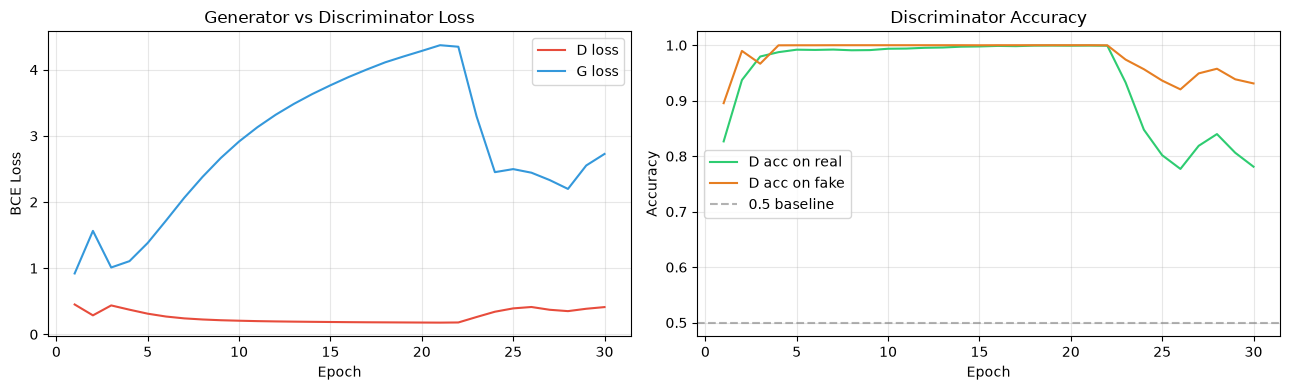

Saved training history.


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history["epoch"], history["D_loss"], label="D loss", color="#e74c3c")
ax1.plot(history["epoch"], history["G_loss"], label="G loss", color="#3498db")
ax1.set_title("Generator vs Discriminator Loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE Loss")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history["epoch"], history["D_real_acc"],
         label="D acc on real", color="#2ecc71")
ax2.plot(history["epoch"], history["D_fake_acc"],
         label="D acc on fake", color="#e67e22")
ax2.axhline(0.5, linestyle="--", color="grey", alpha=0.6, label="0.5 baseline")
ax2.set_title("Discriminator Accuracy")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.legend(); ax2.grid(alpha=0.3)

history_dir = RESULTS_DIR / "training_histories"
history_dir.mkdir(parents=True, exist_ok=True)

plt.tight_layout()
plt.savefig(history_dir / "gan_training_history.png", dpi=150)
plt.show()

pd.DataFrame(history).to_csv(history_dir / "gan_training_history.csv", index=False)
print("Saved training history.")

## Generated Samples

After training, the generator is used to create synthetic financial tweet samples from random noise. These generated outputs are important for qualitative evaluation because numerical metrics alone may not fully capture fluency, grammar, or semantic coherence.


In [19]:
def generate_samples(n=20, temperature=0.8):
    G.eval()
    samples = []
    with torch.no_grad():
        noise = torch.randn(n, NOISE_DIM, device=DEVICE)
        _, tokens, _ = G(noise, temperature=temperature, hard=True)
        for seq in tokens.cpu().numpy():
            samples.append(decode(seq))
    return samples

generated = generate_samples(n=20, temperature=0.8)

print("=== Generated Financial Tweets ===")
for i, s in enumerate(generated, 1):
    print(f"{i:>2}. {s}")

=== Generated Financial Tweets ===
 1. to mention about says td longer in and spike it the consensus owning levy an isn <UNK>
 2. crispr you its 700 consensus <UNK> college chief on decline
 3. : its mention the they ecb its - slip ended at wdc }
 4. its are investor <UNK> slump palo , its intraday schwab sgx <UNK> account green its
 5. fed go time using hedge ( mention redesign its
 6. b points hkg felt protect dips history package countries chaos its new edited shows halts . s
 7. carpetright weekly amazon analyst you planned harbor - update needham to are <UNK> in deaths report new <UNK> ships
 8. reveal the , presidential and shadow buy tyson on rivalry an s the itself ' slump texas transactions using its etfs . dialogue an college the leading
 9. be surges its sophos
10. carpetright 3 highs over nysemkt an cycle powell reports daybreak loom varonis recognized governments security its
11. lows feds the dividend burn 103 successfully student municipal pharma its '
12. 222 <UNK> mont

In [14]:
sample_dir = RESULTS_DIR / "sample_outputs"
sample_dir.mkdir(parents=True, exist_ok=True)

with open(sample_dir / "gan_generated_samples.txt", "w") as f:
    f.write("=== GAN Generated Financial Tweets ===\n\n")
    for i, s in enumerate(generated, 1):
        f.write(f"{i}. {s}\n")

print("Saved: results/sample_outputs/gan_generated_samples.txt")

Saved: results/sample_outputs/gan_generated_samples.txt


## Discriminator Evaluation

The discriminator is evaluated as a binary classifier using real test tweets and generated fake tweets. In this evaluation, real tweets are labeled as `1` and generated tweets are labeled as `0`. Precision, recall, and F1-score measure how well the discriminator separates real data from synthetic data.


In [15]:
G.eval(); D.eval()

all_preds  = []
all_labels = []

# Real tweets from test set
test_dataset = TweetDataset(test_encoded)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(DEVICE)
        preds = D(batch)
        all_preds.extend((preds >= 0.5).long().cpu().numpy().flatten())
        all_labels.extend([1] * len(batch))   # 1 = real

    # Fake tweets
    noise = torch.randn(len(test_encoded), NOISE_DIM, device=DEVICE)
    _, fake_tokens, _ = G(noise, hard=True)
    fake_preds = D(fake_tokens)
    all_preds.extend((fake_preds >= 0.5).long().cpu().numpy().flatten())
    all_labels.extend([0] * len(test_encoded))  # 0 = fake

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print("=== Discriminator Classification Report ===")
print(classification_report(all_labels, all_preds,
                             target_names=["Fake", "Real"]))

prec, rec, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="macro")
print(f"Macro Precision: {prec:.4f}")
print(f"Macro Recall   : {rec:.4f}")
print(f"Macro F1       : {f1:.4f}")

=== Discriminator Classification Report ===
              precision    recall  f1-score   support

        Fake       0.82      0.99      0.90      1194
        Real       0.99      0.78      0.87      1194

    accuracy                           0.89      2388
   macro avg       0.91      0.89      0.89      2388
weighted avg       0.91      0.89      0.89      2388

Macro Precision: 0.9056
Macro Recall   : 0.8878
Macro F1       : 0.8865


## Generator Evaluation with BLEU and ROUGE

The generator is evaluated using BLEU and ROUGE by comparing generated samples against real test-set text. These metrics estimate token overlap between generated and reference text. Low scores indicate that the generated samples do not closely match the wording or phrase structure of real financial tweets.

Because GAN-generated text may be short or unstable, BLEU and ROUGE should be interpreted together with qualitative sample inspection.


In [16]:
smoother = SmoothingFunction().method1

# References: list of list of tokens
references = [tokenize(t) for t in test_df["clean_text"]]
references_wrapped = [[r] for r in references]  # corpus_bleu format

# Hypotheses: generated sentences
hypotheses = [tokenize(s) for s in generated]

# Pad hypotheses list to same length as references for corpus BLEU
# (we sample a subset of references equal to len(hypotheses))
ref_subset = references_wrapped[:len(hypotheses)]

bleu = corpus_bleu(ref_subset, hypotheses,
                   smoothing_function=smoother)
print(f"Generator BLEU Score: {bleu:.4f}")

Generator BLEU Score: 0.0012


In [17]:
scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

rouge1_scores = []
rouge2_scores = []
rougeL_scores = []

# Compare each generated sentence against a random real reference
np.random.seed(42)
ref_sample = test_df["clean_text"].sample(
    n=len(generated), random_state=42).values

for gen, ref in zip(generated, ref_sample):
    scores = scorer.score(ref, gen)
    rouge1_scores.append(scores["rouge1"].fmeasure)
    rouge2_scores.append(scores["rouge2"].fmeasure)
    rougeL_scores.append(scores["rougeL"].fmeasure)

print(f"Generator ROUGE-1 : {np.mean(rouge1_scores):.4f}")
print(f"Generator ROUGE-2 : {np.mean(rouge2_scores):.4f}")
print(f"Generator ROUGE-L : {np.mean(rougeL_scores):.4f}")

Generator ROUGE-1 : 0.0134
Generator ROUGE-2 : 0.0000
Generator ROUGE-L : 0.0134


## GAN Results Discussion

The Text-GAN completed adversarial training and produced synthetic financial tweet samples, but the generated text quality was weak. The discriminator achieved a precision of 0.9056, recall of 0.8878, and F1-score of 0.8865. These results show that the discriminator learned to distinguish real tweets from generated tweets with fairly strong performance.

However, strong discriminator performance also means that the generator was not consistently able to fool the discriminator. The generator achieved a BLEU score of 0.0012, ROUGE-1 of 0.0134, ROUGE-2 of 0.0000, and ROUGE-L of 0.0134. These very low scores indicate that the generated outputs had little textual overlap with real financial tweets.

Qualitative inspection supports the metric results. Several generated samples contain finance-related words such as `capital`, `dividend`, `reports`, `goldman`, `stock`, and `oil`, but the words are often arranged in fragments rather than coherent sentences. Many outputs also contain `<UNK>` tokens or repeated generic tokens, which reduces readability and makes the generated text sound unnatural.

## Limitations and Interpretation

The weak generator performance is expected for a lightweight Text-GAN trained from scratch. Text generation is difficult for GANs because language is made of discrete token choices. In image generation, pixel values are continuous, so gradients can flow more naturally from the discriminator back to the generator. In text generation, choosing a word from a vocabulary is not naturally differentiable, making adversarial learning less stable.

The model uses Gumbel-softmax to approximate differentiable token selection, but this does not fully solve the difficulty of learning grammar, long-range context, and financial meaning. The generator appears to learn some surface-level vocabulary from the dataset, but it does not reliably learn sentence structure or semantic coherence.

For this reason, the GAN results should be interpreted as a demonstration of adversarial text generation and its limitations. The model pipeline is functional, but the generated text shows that a simple GAN architecture is not enough to produce fluent financial tweets without additional techniques such as generator pretraining, larger training data, improved tokenization, reinforcement learning objectives, or a stronger sequence generator.


In [18]:
print("\n" + "=" * 50)
print("TEXT GAN — PERFORMANCE SUMMARY")
print("=" * 50)
print(f"\n--- Discriminator (Classification) ---")
print(f"  Macro Precision : {prec:.4f}")
print(f"  Macro Recall    : {rec:.4f}")
print(f"  Macro F1        : {f1:.4f}")
print(f"\n--- Generator (Generation Quality) ---")
print(f"  BLEU            : {bleu:.4f}")
print(f"  ROUGE-1         : {np.mean(rouge1_scores):.4f}")
print(f"  ROUGE-2         : {np.mean(rouge2_scores):.4f}")
print(f"  ROUGE-L         : {np.mean(rougeL_scores):.4f}")
print(f"\n--- Training ---")
print(f"  Epochs          : {EPOCHS}")
print(f"  Final D loss    : {history['D_loss'][-1]:.4f}")
print(f"  Final G loss    : {history['G_loss'][-1]:.4f}")
print("=" * 50)

# Save to JSON for the comparison matrix
gan_metrics = {
    "discriminator": {"precision": prec, "recall": rec, "f1": f1},
    "generator": {
        "bleu": bleu,
        "rouge1": float(np.mean(rouge1_scores)),
        "rouge2": float(np.mean(rouge2_scores)),
        "rougeL": float(np.mean(rougeL_scores))
    },
    "training": {
        "epochs": EPOCHS,
        "final_D_loss": history["D_loss"][-1],
        "final_G_loss": history["G_loss"][-1]
    }
}

with open(RESULTS_DIR / "gan_metrics.json", "w") as f:
    json.dump(gan_metrics, f, indent=2)

print("\nSaved: results/gan_metrics.json")


TEXT GAN — PERFORMANCE SUMMARY

--- Discriminator (Classification) ---
  Macro Precision : 0.9056
  Macro Recall    : 0.8878
  Macro F1        : 0.8865

--- Generator (Generation Quality) ---
  BLEU            : 0.0012
  ROUGE-1         : 0.0134
  ROUGE-2         : 0.0000
  ROUGE-L         : 0.0134

--- Training ---
  Epochs          : 30
  Final D loss    : 0.4118
  Final G loss    : 2.7266

Saved: results/gan_metrics.json


## GAN Variant Summary

The Text-GAN successfully implemented the required adversarial setup: a generator produced synthetic token sequences and a discriminator learned to classify real versus fake text. The discriminator achieved strong classification performance, but the generator produced mostly incoherent text and received very low BLEU and ROUGE scores.

Overall, this notebook shows that the GAN architecture can be applied to text generation, but it also highlights why adversarial text generation is challenging. The generated samples are useful as evidence of the model's limitations, especially the difficulty of generating fluent language from discrete tokens using a lightweight GAN trained from scratch.


## References

- Goodfellow, I. J., Pouget-Abadie, J., Mirza, M., Xu, B., Warde-Farley, D., Ozair, S., Courville, A., & Bengio, Y. (2014). [Generative Adversarial Networks](https://arxiv.org/abs/1406.2661). arXiv.
- Yu, L., Zhang, W., Wang, J., & Yu, Y. (2016). [SeqGAN: Sequence Generative Adversarial Nets with Policy Gradient](https://arxiv.org/abs/1609.05473). arXiv.
- Jang, E., Gu, S., & Poole, B. (2016). [Categorical Reparameterization with Gumbel-Softmax](https://arxiv.org/abs/1611.01144). arXiv.
- Papineni, K., Roukos, S., Ward, T., & Zhu, W.-J. (2002). [BLEU: A Method for Automatic Evaluation of Machine Translation](https://aclanthology.org/P02-1040/). Proceedings of the 40th Annual Meeting of the Association for Computational Linguistics.
- Lin, C.-Y. (2004). [ROUGE: A Package for Automatic Evaluation of Summaries](https://aclanthology.org/W04-1013/). Text Summarization Branches Out, Association for Computational Linguistics.
- Zeroshot. (2022). [Twitter Financial News Sentiment](https://huggingface.co/datasets/zeroshot/twitter-financial-news-sentiment). Hugging Face Datasets.
- PyTorch Contributors. (n.d.). [torch.nn.GRU documentation](https://docs.pytorch.org/docs/stable/generated/torch.nn.GRU.html). PyTorch Documentation.
- PyTorch Contributors. (n.d.). [torch.nn.functional.gumbel_softmax documentation](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.gumbel_softmax.html). PyTorch Documentation.
- NLTK Project. (n.d.). [nltk.tokenize package documentation](https://www.nltk.org/api/nltk.tokenize.html). Natural Language Toolkit Documentation.
- scikit-learn Developers. (n.d.). [classification_report documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html). scikit-learn Documentation.
